<a href="https://colab.research.google.com/github/srlokygood/traffic-economic-analysis/blob/main/S5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as ptl

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Las librerías se importaron correctamente y el código funciona. Una recomendación: usaste aliases no convencionales (`numpy as py`, `matplotlib.pyplot as mt`, `seaborn as sb`). Los aliases estándar en la comunidad son `np`, `plt` y `sns` — no es un error, pero usarlos facilita que otras personas lean tu código sin confusión.
</div>

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head()

,year,city,country,city_gdp_capita,unemployment_percent,pm2_5,population_m,population
0,2023,buenos-aires,Argentina,15782.0,62.0,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,91.0,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,98.0,"19,10",13.6,13600000.0
3,2023,brasilia,Brazil,15999.0,83.0,"13,50",4.7,4700000.0
4,2023,salvador,Brazil,8761.0,131.0,"16,00",3.9,3900000.0


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato tienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object
- Por lo cual para su mejor manejo es necesario pasarlos a tipo date

In [ ]:
eco.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, son de tipo object
- por lo cual es necesario pasarlos a tipo float para poder usar los valores de mejor manera con calculos numericos
- tambien es recomendable usar en los espacio '_' ya que esto podria evitar errores y posibles caracteres no visibles que dificulten el procesamiento de los datos

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Tus observaciones sobre `traffic` y `eco` son muy completas — identificas correctamente las columnas que necesitan conversión y hasta sugieres proactivamente reemplazar espacios por guiones bajos. ✅
</div>

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic = traffic.rename(columns={
    'Country':'country',
    'City':'city',
    'UpdateTimeUTC':'update_time_utc',
    'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',
    'JamsDelay':'jams_delay',
    'TrafficIndexLive':'traffic_index_live',
    'JamsLengthInKms':'jams_length_kms',
    'JamsCount':'jams_count',
    'MinsDelay':'mins_delay',
    'TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins':'travel_time_hist_per_10kms_mins',
    'MinsDelay':'mins_delay'
})
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'TrafficIndexWeekAgo', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco = eco.rename(columns={
    'Country':'country',
    'City':'city',
    'Year':'year',
    'City GDP/capita':'city_gdp_capita',
    'Unemployment %':'unemployment_percent',
    'PM2.5 (μg/m³)':'pm2_5',
    'Population (M)':'population_m'
})
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_percent',
       'pm2_5', 'population_m', 'population'],
      dtype='object')

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Jair, hay un problema en el renombrado de columnas:

1. En `traffic`, tu diccionario tiene `'country':'Country'` — esto está invertido. El formato correcto de `.rename(columns={...})` es `{nombre_original: nombre_nuevo}`, por lo que debería ser `'Country':'country'`. Como escribiste `'country'` (minúscula, que no existe como columna original), esa línea no hace nada y la columna `Country` queda sin cambiar.
2. En `eco`, no incluiste `City` ni `Year` en el diccionario de renombrado — esas columnas quedan con su nombre original.

El resto de tu código funciona porque usaste consistentemente `'City'`, `'Country'` y `'Year'` (con mayúscula) en los pasos siguientes, pero esto no sigue el formato `snake_case` que pide la rúbrica. Corrige los diccionarios de renombrado para que todas las columnas queden en minúsculas y con guion bajo.
</div>

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2)</b> <a class="tocSkip"></a>

¡Corregido! El renombrado de `eco` ahora incluye `City`, `Country` y `Year`, y el diccionario de `traffic` tiene el orden correcto. Verifiqué el CSV final: `city`, `country` y `year` están en `snake_case` en todas las columnas. ✅
</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   TrafficIndexWeekAgo              1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:

# Limpiar separadores y convertir columnas numéricas
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['unemployment_percent'] = (
    eco['unemployment_percent']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
    .astype(float)
)
eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)
# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  30 non-null     int64  
 1   city                  30 non-null     object 
 2   country               30 non-null     object 
 3   city_gdp_capita       30 non-null     float64
 4   unemployment_percent  30 non-null     float64
 5   pm2_5                 30 non-null     object 
 6   population_m          30 non-null     float64
 7   population            30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_percent,pm2_5,population_m,population
0,2023,buenos-aires,Argentina,15782.0,62.0,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,91.0,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,98.0,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

La conversión de fechas con `pd.to_datetime()` y la limpieza numérica de `eco` (incluyendo la creación de `population`) están correctamente ejecutadas. ✅
</div>


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,TrafficIndexWeekAgo,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024

traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,TrafficIndexWeekAgo,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_percent,pm2_5,population_m,population
15,2024,buenos-aires,Argentina,18117.0,72.0,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,85.0,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,92.0,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,78.0,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,124.0,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:

# Calcular los promedios de tráfico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(
    ["city", "country", "year"]
)[[
    "jams_delay",
    "traffic_index_live",
    "jams_length_kms",
    "jams_count",
    "mins_delay",
    "travel_time_live_per_10kms_mins",
    "travel_time_hist_per_10kms_mins"
]].mean().reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es MEXICO


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_percent','pm2_5','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=['city','year'],how='inner')

# Mostrar las primeras 5 filas
# tu código aquí
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_percent,pm2_5,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,95.0,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,78.0,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,72.0,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,82.0,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.

- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.

- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

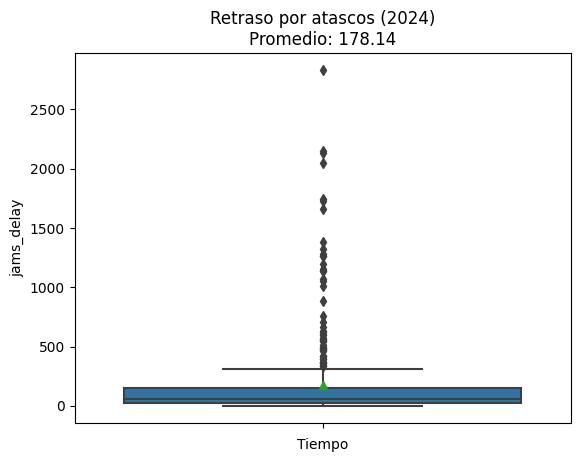

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(data=traffic_2024_small, y='jams_delay',showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = traffic_2024_small['jams_delay'].mean()
ptl.title(f'Retraso por atascos (2024)\nPromedio: {mean_value:.2f}')
ptl.xlabel('Tiempo')
ptl.show()


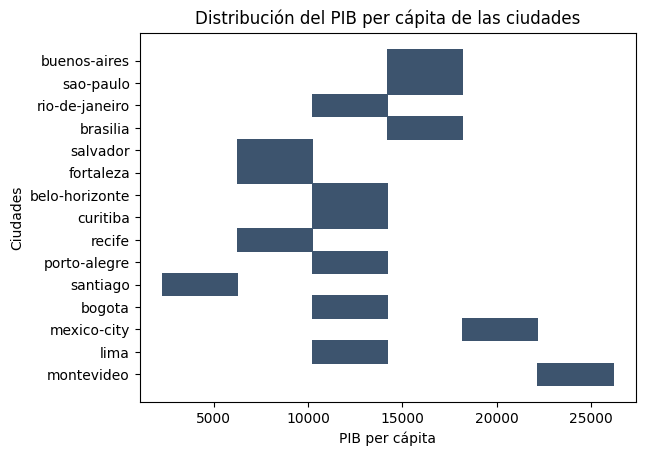

In [ ]:

# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=eco_2024_small,x='city_gdp_capita',y='city')
ptl.title('Distribución del PIB per cápita de las ciudades')
ptl.xlabel('PIB per cápita')
ptl.ylabel('Ciudades')
ptl.show()



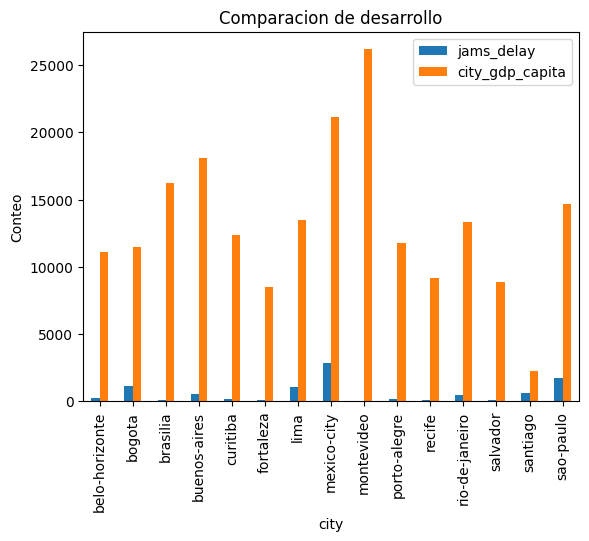

In [ ]:

# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind='bar', y=['jams_delay', 'city_gdp_capita'],x='city')
ptl.title('Comparacion de desarrollo')
ptl.ylabel('Conteo')
ptl.xticks(rotation=90)
ptl.show()

In [ ]:
merged

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_percent,pm2_5,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,95.0,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,78.0,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,72.0,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,82.0,"13,50",3700000.0
5,fortaleza,BRA,2024,82.813181,15.896749,11.205844,24.644991,0.081618,19.267171,19.185554,8512.0,118.0,"14,60",4200000.0
6,lima,PER,2024,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,13472.0,65.0,"19,70",11200000.0
7,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,21111.0,32.0,"22,30",22100000.0
8,montevideo,URY,2024,50.201092,17.014854,6.369201,14.160332,0.393442,18.892342,18.498900,26176.0,84.0,"11,20",1800000.0
9,porto-alegre,BRA,2024,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,11801.0,87.0,"14,20",4300000.0


comentarios:
Análisis resumido

El gráfico no evidencia una correlación clara entre el nivel de atascos y el PBI per cápita. No se observa una tendencia sistemática que relacione ambas variables.

Destacan dos casos opuestos: la ciudad "montevideo" tiene el mayor PBI per cápita y el menor nivel de atascos, mientras que la ciudad "mexico-city", con el segundo PBI más alto, registra la congestión más elevada. Esta contradicción entre ciudades de alto ingreso descarta una relación simple negativa.

Por su parte, la ciudad con menor PBI per cápita muestra un nivel intermedio de atascos, lo que refuerza la ausencia de patrón.

En conclusión, no existe una asociación aparente entre desarrollo económico y retrasos por tráfico en los datos analizados, sugiriendo que otros factores (como infraestructura, densidad o políticas de movilidad) podrían tener mayor incidencia.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

<h2>🧾 Resumen ejecutivo</h2>
<p>
    Para explorar la relación entre <strong>movilidad urbana</strong> y
    <strong>productividad económica</strong>, se vincularon los datos de tráfico
    (congestión y tiempos de viaje) con el <strong>PIB per cápita</strong> de cada ciudad.
    Se utilizaron promedios anuales por ciudad con el fin de identificar posibles
    correlaciones que permitan entender si un mayor desarrollo económico se asocia
    con mejores condiciones de movilidad, y así orientar decisiones de planificación urbana.
</p>
<h2>Contexto y objetivo</h2>
<h3>¿Qué relación existe entre la movilidad urbana y la productividad económica?</h3>
<p>
    A partir de los datos analizados, <strong>no se evidencia una relación clara o consistente</strong>
    entre la congestión vehicular, los tiempos de viaje y el PIB per cápita.
</p>
<p>
    Aunque en algunas ciudades un mayor nivel de congestión está acompañado de mayores
    tiempos de desplazamiento, este comportamiento no parece estar directamente
    relacionado con el nivel de desarrollo económico.
</p>
<p>
    Por ejemplo, <strong>Montevideo</strong> presenta uno de los PIB per cápita más altos
    y, al mismo tiempo, uno de los menores niveles de congestión. En contraste,
    <strong>Ciudad de México</strong>, con un PIB per cápita también elevado, registra
    el mayor nivel de congestión entre las ciudades analizadas.
</p>
<p>
    Esto sugiere que, dentro de este conjunto de datos, el desarrollo económico por sí solo
    <strong>no permite explicar los niveles de congestión o los tiempos de viaje</strong>.
</p>
<h3>Variables clave utilizadas y su relevancia</h3>
<p>
    Para integrar las bases de datos de PIB y movilidad urbana, fue necesario agrupar
    los registros por <strong>ciudad, país y año</strong>, calculando los valores promedio
    cuando existían múltiples registros.
</p>
<p>
    Posteriormente, se utilizaron <strong>ciudad y año</strong> como variables clave para
    relacionar ambas fuentes, permitiendo consolidar la información económica y de
    movilidad en un mismo conjunto de datos.
</p>
<ul>
    <li>
        <strong>PIB per cápita:</strong> utilizado como indicador del nivel de desarrollo
        y productividad económica.
    </li>
    <li>
        <strong>jams_delay:</strong> utilizado como indicador del tiempo de retraso
        ocasionado por la congestión vehicular.
    </li>
    <li>
        <strong>Variables de movilidad:</strong> incluyen índices de tráfico, longitud
        de atascos, cantidad de atascos y tiempos de viaje.
    </li>
</ul>
<p>
    La comparación y visualización de estas variables permitió evaluar si existe alguna
    relación entre el nivel económico de las ciudades y las condiciones de movilidad,
    aportando información útil para identificar patrones y apoyar la toma de decisiones
    relacionadas con <strong>planificación urbana, inversión y transporte</strong>.
</p>
<h2>Cobertura de datos</h2>
<p>
    Para esta investigación se analizaron <strong>15 ciudades de América Latina</strong>
    correspondientes al año <strong>2024</strong>.
</p>
<ul>
    <li>
        <strong>Brasil:</strong> Belo Horizonte, Brasilia, Curitiba, Fortaleza,
        Porto Alegre, Recife, Rio de Janeiro, Salvador y São Paulo.
    </li>
    <li><strong>Argentina:</strong> Buenos Aires.</li>
    <li><strong>Colombia:</strong> Bogotá.</li>
    <li><strong>Chile:</strong> Santiago.</li>
    <li><strong>México:</strong> Ciudad de México.</li>
    <li><strong>Perú:</strong> Lima.</li>
    <li><strong>Uruguay:</strong> Montevideo.</li>
</ul>
<h2>Metodología</h2>
<h3>1. Estandarización de columnas</h3>
<p>
    Se renombraron las variables utilizando nombres claros y consistentes para
    facilitar el manejo y procesamiento de los datos.
</p>
<h3>2. Conversión de formatos</h3>
<ul>
    <li>
        Las fechas se transformaron al formato <code>datetime</code> y se extrajo
        el año de cada registro.
    </li>
    <li>
        Los valores numéricos se convirtieron a tipo <code>float</code>,
        reemplazando comas por puntos para garantizar su correcta interpretación.
    </li>
</ul>
<h3>3. Agregación de los datos</h3>
<p>
    Los registros de tráfico se agruparon por <strong>ciudad, país y año</strong>,
    calculando los valores promedio de las variables disponibles.
</p>
<h3>4. Vinculación de las bases</h3>
<p>
    Posteriormente, se unieron ambos dataframes utilizando
    <strong>ciudad y año</strong> como claves de unión, obteniendo un único
    dataset consolidado.
</p>
<h3>5. Análisis exploratorio</h3>
<p>
    Con los datos integrados, se generaron gráficos de dispersión para visualizar
    la relación entre el <strong>PIB per cápita</strong> y el
    <strong>nivel de congestión</strong> en las ciudades analizadas durante 2024.
</p>
<h2>Agregación e INNER JOIN</h2>
<p>
    Para integrar ambas fuentes de información, primero se estandarizaron los formatos
    de las variables utilizadas como claves de unión.
</p>
<p>
    En la base de tráfico, la columna <code>UpdateTimeUTC</code> se interpretó como fecha,
    se convirtió al formato <code>snake_case</code> como
    <code>update_time_utc</code> y posteriormente se extrajo el año.
</p>
<p>
    De igual manera, la variable <code>City</code> fue estandarizada en ambas bases
    para garantizar que los nombres de las ciudades fueran consistentes.
</p>
<p>
    Finalmente, los datos se agruparon por <strong>ciudad y año</strong>,
    consolidando los registros correspondientes a cada periodo.
</p>
<p>
    Posteriormente, se realizó una unión <strong>INNER JOIN</strong> utilizando
    <code>city</code> y <code>year</code> como claves.
</p>
<p>
    Este tipo de unión permite conservar únicamente los registros que tienen
    coincidencia en ambas fuentes, es decir, ciudades y periodos para los cuales
    existen simultáneamente datos de tráfico y económicos.
</p>
<p>
    De esta manera, se obtiene un conjunto de datos <strong>integrado y consistente</strong>
    para realizar la comparación entre movilidad urbana y desempeño económico.
</p>
<h3>Validaciones visuales</h3>
<ul>
    <li>
        <strong>Distribuciones:</strong> permitieron observar cómo se distribuyen
        las variables económicas y de movilidad.
    </li>
    <li>
        <strong>Outliers:</strong> permitieron identificar ciudades con valores
        significativamente diferentes al resto.
    </li>
    <li>
        <strong>Tendencias generales:</strong> mediante gráficos de dispersión se
        evaluaron posibles relaciones entre el PIB per cápita y las variables de tráfico.
    </li>
</ul>
<h2>Hallazgos iniciales</h2>
<h3>índices de tráfico y PIB per cápita.</h3>
<p>
    
</p>
<h3>Outliers y casos particulares</h3>
<p>
Entre los datos analizados, no se identifica un patrón general y consistente entre el nivel de PIB per cápita y los indicadores de tráfico. Sin embargo, Brasil presenta un comportamiento destacable, ya que combina un nivel relativamente alto de desarrollo económico con bajos niveles de jams_delay. Este comportamiento podría sugerir una relación favorable entre desarrollo económico y movilidad, aunque no es suficiente para establecer una conclusión general.
Es importante considerar que Brasil concentra la mayor cantidad de registros dentro del conjunto de datos, por lo que su comportamiento puede tener una mayor influencia sobre los resultados y generar una posible sobrerrepresentación. Por esta razón, el patrón observado debe interpretarse con cautela y sería necesario analizar la distribución de registros por país para determinar si existe una relación estadísticamente significativa.
</p>
<p>
    Estos casos requieren una revisión adicional para determinar si corresponden
    a características propias de cada ciudad o a diferencias en la cobertura y
    metodología de las fuentes de datos.
</p>
<h2>Recomendaciones</h2>
<ul>
    <li>
        <strong>Priorizar ciudades con alta congestión:</strong> identificar aquellas
        que presentan elevados niveles de retraso y tiempos de viaje para evaluar
        posibles necesidades de inversión en infraestructura y transporte público.
    </li>
    <li>
        <strong>Validar las fuentes:</strong> revisar la calidad, cobertura y
        metodología de los datos económicos y de movilidad antes de tomar decisiones.
    </li>
    <li>
        <strong>Incorporar nuevas variables:</strong> complementar el análisis con
        población, densidad urbana, infraestructura vial, transporte público y
        características territoriales.
    </li>
    <li>
        <strong>Realizar análisis estadístico adicional:</strong> calcular
        coeficientes de correlación y pruebas de significancia para determinar
        si las relaciones observadas son estadísticamente relevantes.
    </li>
</ul>
<h2>Pregunta para la toma de decisiones</h2>
<p>
    ¿Qué ciudad —<strong>Bogotá, Lima, Buenos Aires u otra ciudad analizada</strong>—
    muestra la mayor correlación significativa entre altos niveles de congestión
    vehicular y bajos indicadores de productividad económica?
</p>
<ul>
    <li>
        Montevideo (Uruguay) se destaca como la ciudad con mayor potencial para invertir en infraestructura de transporte, ya que sus condiciones de flujo vehicular podrían aprovecharse para potenciar el rendimiento de la inversión.
Santiago (Chile), con el menor desarrollo económico y tráfico promedio, muestra que considerar solo el tráfico no garantiza mejores resultados.
Un patrón clave es que la mayoría de ciudades con mejor desempeño económico y menor congestión son brasileñas: Curitiba, Fortaleza, Belo Horizonte, Brasilia, Porto Alegre, Recife y Salvador. Esto sugiere que el éxito responde más a factores estructurales de Brasil que a una relación directa entre tráfico y productividad.
Conclusión: Montevideo es la mejor opción para invertir, pero el tráfico por sí solo no explica el desarrollo económico; deben considerarse otros factores contextuales.
    </li>
</ul>
